# Infinite Potential Wells

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#%pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display

from scipy.special import jv, jn_zeros
#from scipy.special import spherical_jn, sph_harm_y
#import scipy.optimize
#from scipy.integrate import simpson

# 1D Infinite Square Well

# The 1D Infinite Square Well

The one-dimensional infinite square well is one of the simplest and most important exactly solvable systems in quantum mechanics. It describes a particle confined to a region of finite width $a$, with infinitely high potential barriers preventing the particle from existing outside that region. The potential energy is therefore

$$
V(x) =
\begin{cases}
0, & 0 < x < a,\\
\infty, & \text{otherwise}.
\end{cases}
$$

Because the potential is infinite outside the interval $0<x<a$, the particle must be confined entirely within the well. In particular, its wavefunction must vanish at the boundaries:

$$
\psi(0)=\psi(a)=0.
$$

## Deriving the Energy Eigenstates

Inside the well, where $V(x)=0$, the time-independent Schrödinger equation is

$$
-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2}
=E\psi.
$$

Rearranging gives

$$
\frac{d^2\psi}{dx^2}
+\frac{2mE}{\hbar^2}\psi=0.
$$

Defining

$$
k^2=\frac{2mE}{\hbar^2},
$$

the equation becomes

$$
\frac{d^2\psi}{dx^2}+k^2\psi=0.
$$

The general solution is a linear combination of sine and cosine functions:

$$
\psi(x)=A\sin(kx)+B\cos(kx).
$$

Applying the first boundary condition, $\psi(0)=0$, gives

$$
0=A\sin(0)+B\cos(0)=B,
$$

so $B=0$. The wavefunction therefore reduces to

$$
\psi(x)=A\sin(kx).
$$

The second boundary condition requires $\psi(a)=0$, giving

$$
A\sin(ka)=0.
$$

For a nontrivial wavefunction, $A\neq0$, so we must have

$$
\sin(ka)=0.
$$

This occurs whenever

$$
ka=n\pi,
\qquad n=1,2,3,\ldots
$$

and therefore

$$
k_n=\frac{n\pi}{a}.
$$

Since $k^2=2mE/\hbar^2$, the allowed energy eigenvalues are

$$
\boxed{
E_n=\frac{n^2\pi^2\hbar^2}{2ma^2},
\qquad n=1,2,3,\ldots
}
$$

Thus, unlike a classical particle whose energy can take any positive value, a quantum particle in an infinite square well can only possess these discrete energies.



In [11]:
fig_out1 = widgets.Output()

m = 1
a = 1
x = np.linspace(0, a, 1001)

kvals = np.array([n*np.pi/a for n in range(1, 8)])
kdense = np.linspace(0, kvals[-1], 1001)

# Create widgets
kvec = widgets.FloatSlider(
    value=0, min=0, max=kvals[-1], step=0.001,
    description="$k$"
)

def render1(change=None):
    k = kvec.value

    with fig_out1:
        fig_out1.clear_output(wait=True)

        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))

        ax0.plot(x, np.sqrt(2/a)*np.sin(k*x/a), 'k')
        
        
        ax0.axhline(0, color = 'k', alpha = 0.2)
        ax0.axvline(0, color = 'k', alpha = 0.2)
        ax0.axvline(a, color = 'k', alpha = 0.2)
        
        ax0.set_xlabel(r'$x/a$')
        ax0.text(0.5, 2, r'$\psi(x)$', fontsize = 14)
        ax0.set_ylim(-2, 2.5)
               
        ax1.plot(kvals, kvals**2/(2*m), 'k.')
        ax1.plot(kdense, kdense**2/(2*m), 'k', alpha = 0.1)
        ax1.axvline(k, color = 'r')
        ax1.set_xlim(0, kvals[-1])
        
        ax1.set_xlabel(r'$k$')
        ax1.set_ylabel(r'$E=\frac{\hbar^2 k^2}{2m}$')
    
        #ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
        #ax1.set_yticks([0,1, 2], [r'$0$',r'$\sqrt{\kappa/m}$', r'$2\sqrt{\kappa/m}$'])

        plt.tight_layout()
        plt.show()

kvec.observe(render1, names="value")

display(kvec, fig_out1)
render1()

FloatSlider(value=0.0, description='$k$', max=21.991148575128552, step=0.001)

Output()

For the free particle, there is no restriction on the values of $k$, and so the particle has a **continuous** energy spectrum. 

For the infinite square well, although the solutions are still lane waves, only certain values of $k$ are allowed, and the system has a **discrete** energy spectrum.

## Normalizing the Wavefunctions

The corresponding eigenfunctions have the form

$$
\psi_n(x)=A\sin\left(\frac{n\pi x}{a}\right).
$$

To determine $A$, we impose the normalization condition

$$
\int_0^a |\psi_n(x)|^2\,dx=1.
$$

Substituting the wavefunction gives

$$
|A|^2\int_0^a
\sin^2\left(\frac{n\pi x}{a}\right)\,dx=1.
$$

The integral evaluates to $a/2$, so

$$
|A|^2\frac{a}{2}=1.
$$

Choosing $A$ to be real and positive gives

$$
A=\sqrt{\frac{2}{a}}.
$$

Hence the normalized stationary states are

$$
\boxed{
\psi_n(x)=
\sqrt{\frac{2}{a}}
\sin\left(\frac{n\pi x}{a}\right),
\qquad 0<x<a.
}
$$

The wavefunction is zero outside the well.

## Final Result

The infinite square well therefore has a discrete set of normalized energy eigenstates,

$$
\boxed{
\psi_n(x)=
\begin{cases}
\sqrt{\frac{2}{a}}
\sin\left(\frac{n\pi x}{a}\right), & 0<x<a,\\[6pt]
0, & \text{otherwise},
\end{cases}
}
$$

with corresponding energies

$$
\boxed{
E_n=\frac{n^2\pi^2\hbar^2}{2ma^2},
\qquad n=1,2,3,\ldots
}
$$

The integer $n$ is the quantum number labeling the allowed stationary states. The lowest possible energy,

$$
E_1=\frac{\pi^2\hbar^2}{2ma^2},
$$

is nonzero, illustrating the quantum-mechanical phenomenon of **zero-point energy**: even in its ground state, the particle cannot have zero energy.

## 2D Infinite Square Well 

Consider a particle of mass $m$ confined to a two-dimensional square region of width $L$. The potential is

$$
V(x, y) =
\begin{cases}
0, & 0 < x < L \text{ and } 0 < y < L, \\
\infty, & \text{otherwise}
\end{cases}
$$

Inside the well, the time-independent Schrödinger equation is therefore

$$
-\frac{\hbar^2}{2m}\nabla^2\psi = -\frac{\hbar^2}{2m}\bigg(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}\bigg) \psi =  E\psi
$$

We can simplify the above partial differential equation by looking for separable solutions, i.e wavefunctions of the form 

$$ \Psi(x,y) = X(x)Y(y).  $$

Inserting this ansatz into the Schrodinger equation, we obtain 

$$ -\frac{\hbar^2}{2m}\bigg(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}\bigg)X(x)Y(y) = E X(x)Y(y)$$ 

$$ X''(x)Y(y) + X(x)Y''(y) = -\frac{2m}{\hbar^2}E X(x)Y(y)$$ 

Dividing through by $X(x)Y(y)$, we find that 

$$ \frac{X''(x)}{X(x)} + \frac{Y''(y)}{Y(y)} = -\frac{2m}{\hbar^2}E$$ 

Note that the first term depends only on $x$, the second term depends only on $y$, and the RHS has no spatial dependence at all, i.e., it is a constant. This is only possible if the first two terms are themselves constant. If they were not, we could just adjust the value the first term by varying $x$ by some amount while keeping $y$ fixed, and the RHS would *have* to change - a contradiction. We must therefore have that, for some $E_x + E_y = E$, that

$$  X'' = -\frac{2m}{\hbar^2 }E_x X = -k_x^2 X$$

and 

$$  Y'' = -\frac{2m}{\hbar^2 }E_t Y = -k_y^2 Y$$

For the same reasons as in the 1D case, we must impose that the wavefunction vanishes at the boundaries of the square, i.e., that $ X(0) = X(L) = 0 = Y(0) = Y(L) $. But that makes these two separated problems identical to the one we just solved in 1D. 

$$ X(x) = \sqrt{\frac{2}{L}} \sin \bigg( \frac{k_x\pi}{L}\bigg) $$

$$ Y(y) = \sqrt{\frac{2}{L}} \sin \bigg( \frac{k_y\pi}{L}\bigg) $$

and therefore 

$$ \Psi(x, y) =  \frac{2}{L} \sin \bigg( \frac{k_x\pi}{L}\bigg) \sin \bigg( \frac{k_y\pi}{L}\bigg) $$

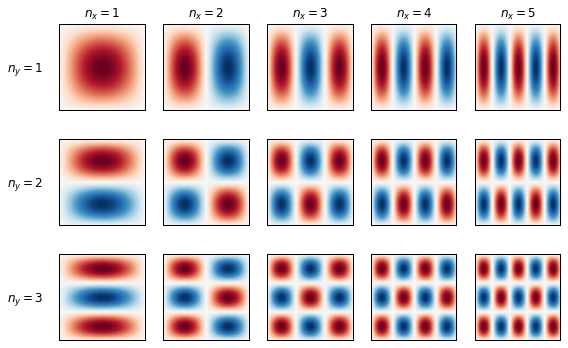

In [9]:
# 2D Square Well Wavefunctions

N= 500
L=1
x, y = np.linspace(0, L, N), np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

mvals = np.arange(1, 6)
nvals = np.arange(1, 4)
fig, axs = plt.subplots(len(nvals), len(mvals), figsize = (9,6))

def plot_wavefunction(axs, m, n):
    psi = np.sin(np.pi*m*X)*np.sin(np.pi*n*Y)

    pmax = np.amax(psi)
    pmin = np.amin(psi)
    pext = max(pmax, -pmin)

    axs.imshow(psi, vmin=-pext, vmax = pext, cmap='RdBu_r', extent =[0, 1, 0, 1])
    
    axs.plot([0, 0], [0,1], 'k', lw=2)
    axs.plot([1, 1], [0,1], 'k', lw=2)
    axs.plot([0, 1], [0,0], 'k', lw=2)
    axs.plot([0, 1], [1,1], 'k', lw=2)
    
    axs.set_axis_off()
    

for i, m in enumerate(mvals):
    for j, n in enumerate(nvals):
        plot_wavefunction(axs[j, i], m, n)

fs = 12
axs[0, 0].text(-0.6, 0.45, r'$n_y=1$', fontsize=fs)
axs[1, 0].text(-0.6, 0.45, r'$n_y=2$', fontsize=fs)
axs[2, 0].text(-0.6, 0.45, r'$n_y=3$', fontsize=fs)

axs[0, 0].set_title(r'$n_x=1$', fontsize=fs)
axs[0, 1].set_title(r'$n_x=2$', fontsize=fs)
axs[0, 2].set_title(r'$n_x=3$', fontsize=fs)
axs[0, 3].set_title(r'$n_x=4$', fontsize=fs)
axs[0, 4].set_title(r'$n_x=5$', fontsize=fs)
    
#plt.tight_layout()
    
plt.show()

# 2D Infinite Circular Well

Consider a particle of mass $m$ confined to a two-dimensional circular region of radius $R$. The potential is

$$
V(r) =
\begin{cases}
0, & 0 \leq r < R, \\
\infty, & r \geq R.
\end{cases}
$$

Inside the well, the time-independent Schrödinger equation is therefore

$$
-\frac{\hbar^2}{2m}\nabla^2\psi = E\psi.
$$

Because the boundary is circular, it is natural to use polar coordinates $(r,\phi)$. In two dimensions, the Laplacian is

$$
\nabla^2 =
\frac{1}{r}\frac{\partial}{\partial r}
\left(r\frac{\partial}{\partial r}\right)
+
\frac{1}{r^2}\frac{\partial^2}{\partial \phi^2}.
$$

Thus the Schrödinger equation becomes

$$
-\frac{\hbar^2}{2m}
\left[
\frac{1}{r}\frac{\partial}{\partial r}
\left(r\frac{\partial\psi}{\partial r}\right)
+
\frac{1}{r^2}\frac{\partial^2\psi}{\partial\phi^2}
\right]
=E\psi.
$$

We use separation of variables and write

$$
\psi(r,\phi)=R(r)\Phi(\phi).
$$

Substituting this into the Schrödinger equation and multiplying through by
$-2mr^2/\hbar^2R\Phi$ gives

$$
\frac{r}{R}\frac{d}{dr}
\left(r\frac{dR}{dr}\right)
+
\frac{2mEr^2}{\hbar^2}
+
\frac{1}{\Phi}\frac{d^2\Phi}{d\phi^2}
=0.
$$

The radial and angular terms must separately equal a constant. We choose the
separation constant to be $-\ell^2$, giving the angular equation

$$
\frac{d^2\Phi}{d\phi^2}+\ell^2\Phi=0.
$$

The solutions are

$$
\Phi(\phi)=Ae^{i\ell\phi}+Be^{-i\ell\phi}.
$$

Because the wavefunction must be single-valued after a complete rotation,

$$
\Phi(\phi+2\pi)=\Phi(\phi),
$$

we require

$$
\ell = 0,\pm1,\pm2,\ldots
$$

and the normalized angular solutions can be written as

$$
\Phi_\ell(\phi)=\frac{1}{\sqrt{2\pi}}e^{i\ell\phi}.
$$

The radial equation is

$$
r^2\frac{d^2R}{dr^2}
+r\frac{dR}{dr}
+
\left(
\frac{2mE}{\hbar^2}r^2-\ell^2
\right)R=0.
$$

Defining

$$
k^2=\frac{2mE}{\hbar^2},
$$

this becomes

$$
r^2\frac{d^2R}{dr^2}
+r\frac{dR}{dr}
+
(kr)^2R-\ell^2R=0.
$$

This is Bessel's differential equation. Its two linearly independent solutions are
the Bessel functions of the first and second kind,

$$
R(r)=C J_\ell(kr)+D Y_\ell(kr).
$$



In [ ]:
# Plots of Bessel functions

The functions $Y_\ell(kr)$ diverge at $r=0$, so physical solutions must have
$D=0$. Therefore,

$$
R(r)=C J_\ell(kr).
$$

The infinite potential at $r=R$ requires the wavefunction to vanish at the
boundary:

$$
\psi(R,\phi)=0.
$$

Consequently,

$$
R(R)=0,
$$

which gives

$$
J_\ell(kR)=0.
$$

In other words, we are after the values of $k$ that make the Bessel function vanish at $r=R$, just like how in 1D we were after the values of $k$ that made the sine function vanish at $x=a$. Although we do not have the luxury of a simple closed form expression this time, the physics are essentially the same, as shown in the widget below. 

The zeros of the Bessel functions have been well-studied, and `scipy.special.jn_zeros` will even generate them for you. 

In [ ]:
# k-varying widget, but for Bessel function instead of sine

Let $j_{\ell,n}$ denote the $n$th positive zero of the Bessel function
$J_\ell$. Then the allowed wave numbers are

$$
k_{\ell,n}=\frac{j_{\ell,n}}{R},
\qquad n=1,2,3,\ldots
$$

and hence the energy eigenvalues are

$$
E_{\ell,n}
=
\frac{\hbar^2 k_{\ell,n}^2}{2m}
=
\frac{\hbar^2}{2mR^2}j_{\ell,n}^2.
$$

The corresponding spatial eigenfunctions are therefore

$$
\psi_{\ell,n}(r,\phi)
=
N_{\ell,n}
J_\ell\left(\frac{j_{\ell,n}r}{R}\right)
e^{i\ell\phi},
$$

where $N_{\ell,n}$ is a normalization constant.

Using the orthogonality relation for Bessel functions,

$$
\int_0^R
r
J_\ell\left(\frac{j_{\ell,n}r}{R}\right)
J_\ell\left(\frac{j_{\ell,n'}r}{R}\right)
\,dr
=
\frac{R^2}{2}
[J_{\ell+1}(j_{\ell,n})]^2
\delta_{nn'},
$$

and requiring

$$
\int_0^{2\pi}\int_0^R
|\psi_{\ell,n}(r,\phi)|^2
r\,dr\,d\phi=1,
$$

we obtain

$$
N_{\ell,n}
=
\frac{1}
{\sqrt{\pi}\,R\,|J_{\ell+1}(j_{\ell,n})|}.
$$

Thus the normalized eigenfunctions can be written as

$$
\boxed{
\psi_{\ell,n}(r,\phi)
=
\frac{
J_\ell\left(j_{\ell,n}r/R\right)
e^{i\ell\phi}
}{
\sqrt{\pi}\,R\,|J_{\ell+1}(j_{\ell,n})|}
}
$$

with corresponding energies

$$
\boxed{
E_{\ell,n}
=
\frac{\hbar^2}{2mR^2}j_{\ell,n}^2
}.
$$

The full time-dependent stationary states are obtained by multiplying the
spatial eigenfunctions by the usual time-dependent phase,

$$
\Psi_{\ell,n}(r,\phi,t)
=
\psi_{\ell,n}(r,\phi)
e^{-iE_{\ell,n}t/\hbar}.
$$

An important feature of the circular well is that the energy depends on
$\ell^2$ through the Bessel-function zeros, so states with $+\ell$ and $-\ell$
have the same energy. Thus, for $\ell\neq0$, the energy levels are generally
two-fold degenerate. The $\ell=0$ states are nondegenerate.

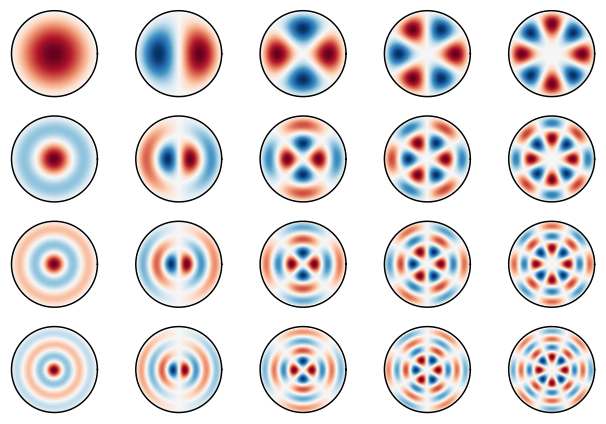

In [10]:
# 2D Circular Well Wavefunctions

N= 500
radius=1
x, y = np.linspace(-radius, radius, N), np.linspace(-radius, radius, N)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
T = np.arctan2(Y, X)

t = np.linspace(0, 2*np.pi, 1000) # For parameterizing outline

OOB_mask = R > radius
IB_mask = R < radius

mvals = np.arange(5)
nvals = np.arange(4)
fig, axs = plt.subplots(4, 5, figsize = (9,6))

def plot_2D_wavefunction(axs, m, n):
    zeros = jn_zeros(m, n+1) # Zeros of Bessel function
    psi = jv(m, R*zeros[n])*np.cos(m*T) # Wavefunction

    pmax = np.amax(psi[IB_mask])
    pmin = np.amin(psi[IB_mask])
    pext = max(pmax, -pmin)
    psi[OOB_mask] = float('nan')
    axs.imshow(psi, vmin=-pext, vmax = pext, cmap='RdBu_r', extent =[-1, 1, -1, 1])

    axs.plot(np.cos(t), np.sin(t), 'k')
    axs.set_xlim(-1.1, 1.1)
    axs.set_ylim(-1.1, 1.1)
    
    axs.set_axis_off()
    
for i, m in enumerate(mvals):
    for j, n in enumerate(nvals):
        plot_2D_wavefunction(axs[j, i], m, n)
        
plt.tight_layout()
    
plt.show()

# 3D Infinite Spherical Well

Consider a particle of mass $m$ confined to a three-dimensional spherical region
of radius $R$. The potential is

$$
V(r) =
\begin{cases}
0, & 0 \leq r < R, \\
\infty, & r \geq R.
\end{cases}
$$

Inside the well, the time-independent Schrödinger equation is

$$
-\frac{\hbar^2}{2m}\nabla^2\psi = E\psi.
$$

Because the boundary is spherical, it is natural to use spherical coordinates
$(r,\theta,\phi)$. The Laplacian in spherical coordinates is

$$
\nabla^2 =
\frac{1}{r^2}\frac{\partial}{\partial r}
\left(
r^2\frac{\partial}{\partial r}
\right)
+
\frac{1}{r^2\sin\theta}
\frac{\partial}{\partial\theta}
\left(
\sin\theta\frac{\partial}{\partial\theta}
\right)
+
\frac{1}{r^2\sin^2\theta}
\frac{\partial^2}{\partial\phi^2}.
$$

Thus, inside the spherical well,

$$
-\frac{\hbar^2}{2m}
\left[
\frac{1}{r^2}\frac{\partial}{\partial r}
\left(
r^2\frac{\partial\psi}{\partial r}
\right)
+
\frac{1}{r^2\sin\theta}
\frac{\partial}{\partial\theta}
\left(
\sin\theta\frac{\partial\psi}{\partial\theta}
\right)
+
\frac{1}{r^2\sin^2\theta}
\frac{\partial^2\psi}{\partial\phi^2}
\right]
=E\psi.
$$

We use separation of variables and write the wavefunction as

$$
\psi(r,\theta,\phi)
=
R(r)\Theta(\theta)\Phi(\phi).
$$

The angular part of the Schrödinger equation leads to the spherical harmonics.
The angular eigenfunctions are denoted by

$$
Y_\ell^m(\theta,\phi),
$$

where

$$
\ell=0,1,2,\ldots
$$

and

$$
m=-\ell,-\ell+1,\ldots,\ell-1,\ell.
$$

The spherical harmonics satisfy the angular momentum eigenvalue equation

$$
\hat L^2Y_\ell^m
=
\hbar^2\ell(\ell+1)Y_\ell^m.
$$

They are also orthonormal according to

$$
\int_0^{2\pi}\int_0^\pi
Y_{\ell}^{m*}(\theta,\phi)
Y_{\ell'}^{m'}(\theta,\phi)
\sin\theta\,d\theta\,d\phi
=
\delta_{\ell\ell'}\delta_{mm'}.
$$

After separating the angular dependence, the radial equation becomes

$$
-\frac{\hbar^2}{2m}
\left[
\frac{1}{r^2}\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)
-
\frac{\ell(\ell+1)}{r^2}R
\right]
=
ER.
$$

Defining

$$
k^2=\frac{2mE}{\hbar^2},
$$

the radial equation can be written as

$$
\frac{1}{r^2}\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)
+
\left[
k^2-\frac{\ell(\ell+1)}{r^2}
\right]R
=0.
$$

Expanding the derivative gives

$$
\frac{d^2R}{dr^2}
+
\frac{2}{r}\frac{dR}{dr}
+
\left[
k^2-\frac{\ell(\ell+1)}{r^2}
\right]R
=0.
$$

This is the spherical Bessel differential equation. Its solutions are the
spherical Bessel functions of the first and second kinds,

$$
R(r)
=
A j_\ell(kr)
+
B y_\ell(kr).
$$

In [12]:
# Plots of spherical Bessel Functions

The spherical Bessel functions $y_\ell(kr)$ diverge at $r=0$. Since the
wavefunction must remain finite at the origin, we require

$$
B=0.
$$

Therefore, the physically acceptable radial solution is

$$
R(r)=A j_\ell(kr).
$$

The infinite potential at $r=R$ requires the wavefunction to vanish at the
boundary:

$$
\psi(R,\theta,\phi)=0.
$$

Therefore,

$$
R(R)=0,
$$

which gives

$$
j_\ell(kR)=0.
$$



In [ ]:
# 

Let $x_{\ell n}$ denote the $n$th positive zero of the spherical Bessel
function $j_\ell(x)$. Then the allowed wave numbers are

$$
k_{\ell n}
=
\frac{x_{\ell n}}{R},
\qquad
n=1,2,3,\ldots
$$

and therefore the allowed energies are

$$
E_{\ell n}
=
\frac{\hbar^2 k_{\ell n}^2}{2m}
=
\frac{\hbar^2}{2mR^2}x_{\ell n}^2.
$$

The spherical Bessel functions are related to ordinary Bessel functions by

$$
j_\ell(x)
=
\sqrt{\frac{\pi}{2x}}
J_{\ell+1/2}(x).
$$

Consequently, the zeros $x_{\ell n}$ are also the zeros of

$$
J_{\ell+1/2}(x).
$$

The spatial eigenfunctions therefore have the form

$$
\psi_{\ell m n}(r,\theta,\phi)
=
N_{\ell n}
j_\ell\left(\frac{x_{\ell n}r}{R}\right)
Y_\ell^m(\theta,\phi),
$$

where $N_{\ell n}$ is a normalization constant.

To normalize the radial part, we use the orthogonality relation

$$
\int_0^R
r^2
j_\ell\left(\frac{x_{\ell n}r}{R}\right)
j_\ell\left(\frac{x_{\ell n'}r}{R}\right)
\,dr
=
\frac{R^3}{2}
\left[
j_{\ell+1}(x_{\ell n})
\right]^2
\delta_{nn'}.
$$

Since the spherical harmonics are already normalized, the normalization
condition

$$
\int
|\psi_{\ell mn}|^2\,d^3r
=1
$$

gives

$$
N_{\ell n}
=
\frac{\sqrt{2}}
{R^{3/2}
\left|
j_{\ell+1}(x_{\ell n})
\right|}.
$$

Thus the normalized eigenfunctions can be written as

$$
\boxed{
\psi_{\ell mn}(r,\theta,\phi)
=
\frac{\sqrt{2}}
{R^{3/2}
\left|
j_{\ell+1}(x_{\ell n})
\right|}
j_\ell\left(\frac{x_{\ell n}r}{R}\right)
Y_\ell^m(\theta,\phi)
}
$$

with corresponding energy eigenvalues

$$
\boxed{
E_{\ell n}
=
\frac{\hbar^2}{2mR^2}x_{\ell n}^2
}.
$$

The full time-dependent stationary states are obtained by multiplying the
spatial eigenfunctions by the usual time-dependent phase,

$$
\Psi_{\ell mn}(r,\theta,\phi,t)
=
\psi_{\ell mn}(r,\theta,\phi)
e^{-iE_{\ell n}t/\hbar}.
$$

An important feature of the spherical well is that the energy depends on
$\ell$ and $n$, but not on the magnetic quantum number $m$. For a given value
of $\ell$, there are

$$
2\ell+1
$$

possible values of $m$. Therefore, every energy level with $\ell>0$ has a
degeneracy of $2\ell+1$.

For example, for $\ell=0$, the spherical Bessel function is

$$
j_0(x)=\frac{\sin x}{x}.
$$

Its zeros occur at

$$
x_{0n}=n\pi,
\qquad n=1,2,3,\ldots
$$

so the $\ell=0$ energy levels reduce to

$$
E_{0n}
=
\frac{\hbar^2\pi^2n^2}{2mR^2}.
$$

The corresponding radial wavefunctions are proportional to

$$
j_0\left(\frac{n\pi r}{R}\right)
=
\frac{
\sin(n\pi r/R)
}{
n\pi r/R
}.
$$

Thus, the 3D infinite spherical well is characterized by spherical Bessel
functions in the radial direction and spherical harmonics in the angular
directions, with the boundary condition $j_\ell(kR)=0$ quantizing the allowed energies.

In [4]:
def sphericalBesselBrent(x, n):
    return spherical_jn(n, x)

def spherical_jn_zeros(n, num_zeros):

    """
    Determines the first few zeros of the spherical Bessel function of the first kind.
    Useful for plotting radial wavefunctions for the infinite spherical well. 
    
    """
    zeros=[]
    
    # Updating bounds
    left = 1
    right= left+np.pi

    while len(zeros)<num_zeros:
        try:
            x0 = scipy.optimize.brentq(sphericalBesselBrent, left, right, args = (n))
            zeros.append(x0)
            left =x0+0.1
            right=left+np.pi
        except:
            right+=np.pi
    
    return zeros

## Spherical Well Wavefunctions

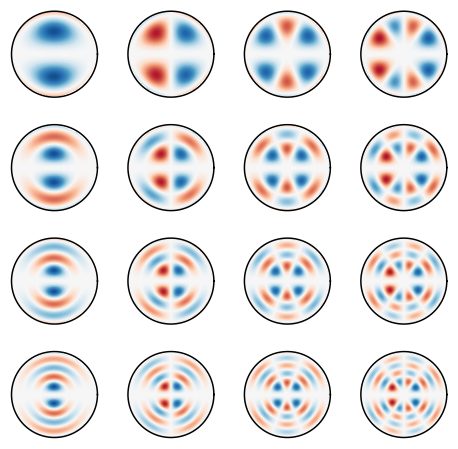

In [28]:
# 3D Spherical Well Wavefunctions
from scipy.special import sph_harm

N= 100
radius=1
x =np.linspace(-radius, radius, N)
y =np.linspace(-radius, radius, N)
z =np.linspace(-radius, radius, N)

X, Y, Z = np.meshgrid(x, y, z)

R = np.sqrt(X**2 + Y**2 +Z**2)
T = np.arccos(Z/R)
P = np.arctan2(Y, X)

t = np.linspace(0, 2*np.pi, 1000) # For parameterizing outline

OOB_mask = R > radius
IB_mask = R < radius

lvals = np.arange(2, 6)
nvals = np.arange(0, 4)
m=2
fig, axs = plt.subplots(len(nvals), len(lvals), figsize = (8,8))


def plot_3D_wavefunction(axs, l, m, n):
    zeros = spherical_jn_zeros(l, n+1) # Zeros of Bessel function
    
    Y = sph_harm(m, l, P, T)

    # Linear combination of Y_l,m and Y_l,-m to create the real form.
    if m < 0:
        Y = np.sqrt(2) * (-1)**m * Y.imag
    elif m > 0:
        Y = np.sqrt(2) * (-1)**m * Y.real
    
    psi = jv(l, R*zeros[n])*np.real(Y) # Wavefunction
    psi_slice = psi[:, N//2, :]
    
    pmax = np.amax(psi_slice)
    pmin = np.amin(psi_slice)
    pext = max(pmax, -pmin)
    psi[OOB_mask] = float('nan')
    
    axs.imshow(psi_slice, vmin=-0.3, vmax = 0.3, cmap='RdBu_r', extent =[-1, 1, -1, 1])

    axs.plot(np.cos(t), np.sin(t), 'k')
    axs.set_xlim(-1.1, 1.1)
    axs.set_ylim(-1.1, 1.1)
    
    axs.set_axis_off()
    

for i, l in enumerate(lvals):
    for j, n in enumerate(nvals):
        plot_3D_wavefunction(axs[j, i], l, m, n)
    
plt.show()

# Scratch

## Radial Function Comparison

<IPython.core.display.Javascript object>


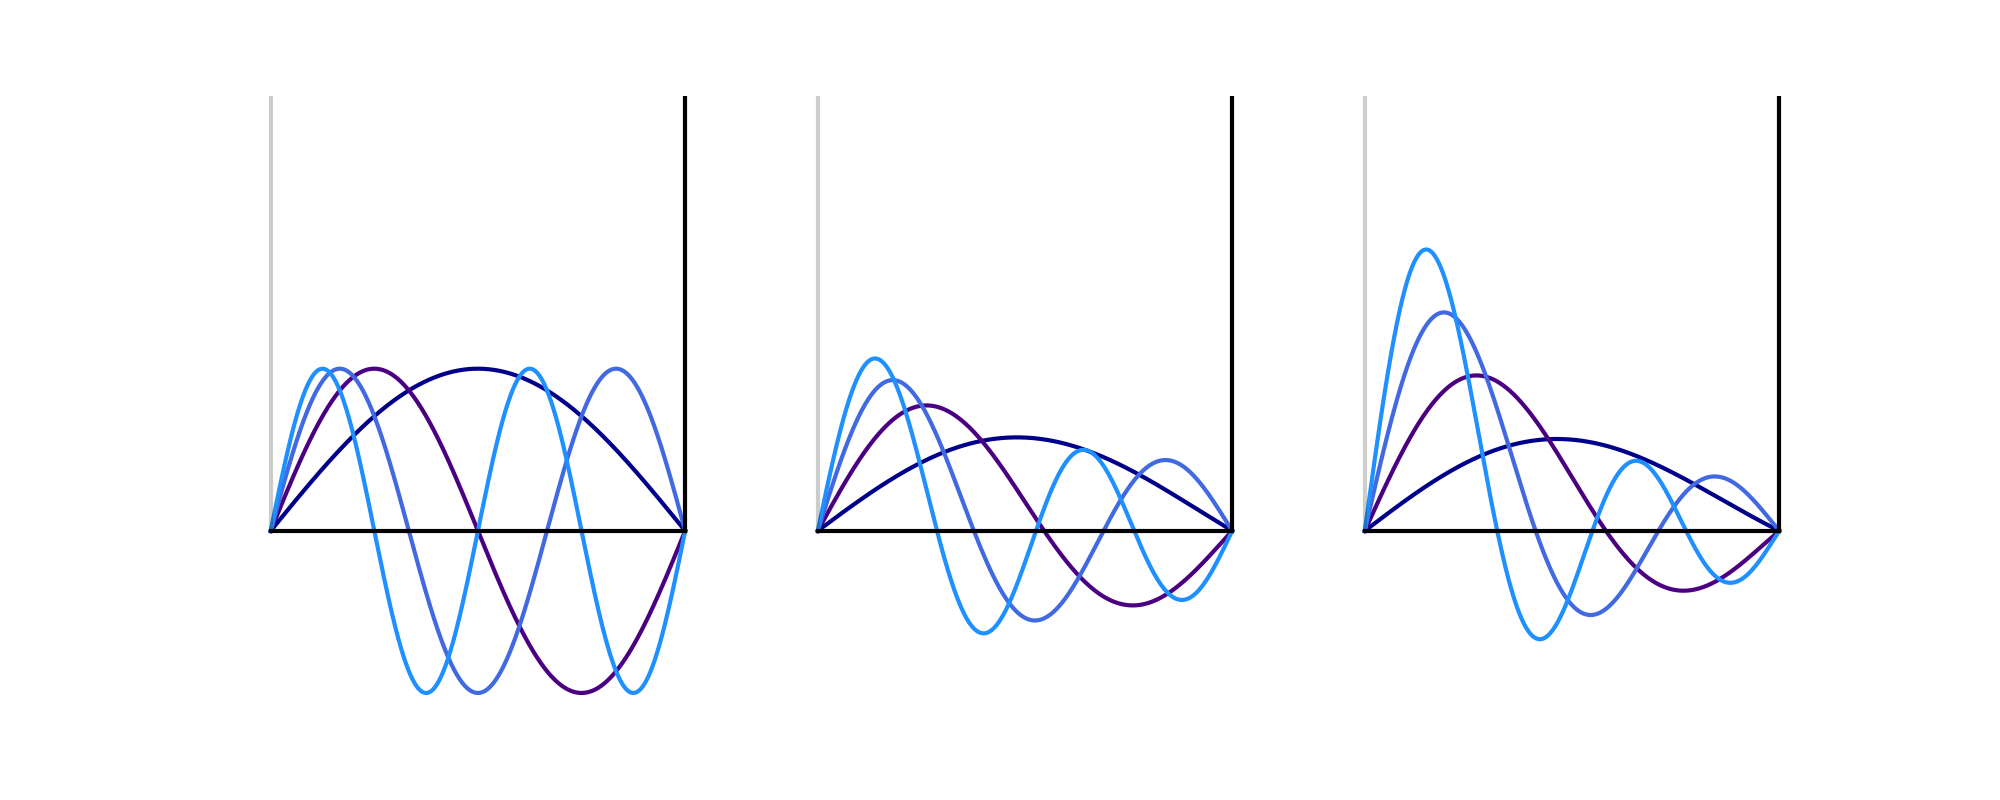

In [11]:
fig, axs = plt.subplots(1, 3, figsize = (10,4))

#Plot cycle
colors = ['darkblue', 'indigo', 'royalblue', 'dodgerblue']
custom_cycler = (cycler(color=colors) +
                 cycler(lw=[1.5 for c in colors]))

for k in range(3):
    axs[k].set_prop_cycle(custom_cycler)

x = np.linspace(0, 1, 1000)

num_zeros = 4 # Number of solutions to show

ymax = 0.12
ymin = -0.05

for k in range(1, num_zeros+1):
    y = np.sin(np.pi*k*x)
    y = y/np.sqrt(simps(y**2))
    axs[0].plot(x, y)

m = 1 # Order of the Bessel function
zeros = jn_zeros(m, num_zeros)
for i, zi in enumerate(zeros):
    y = jv(m, x*zi)
    y = y/np.sqrt(simps(x*y**2))
    axs[1].plot(x, y/np.sqrt(2*np.pi))

l = 1 # Order of the spherical Bessel function
zeros = spherical_jn_zeros(l, num_zeros)
for i, zi in enumerate(zeros):
    y=spherical_jn(l, x*zi)
    y = y/np.sqrt(simps(x**2 *y**2))
    axs[2].plot(x, y/np.sqrt(4*np.pi))
    
for k in range(3):
    axs[k].plot([0, 1], [0,0], 'k')
    axs[k].plot([0, 0], [0,ymax], 'k', alpha = 0.2)
    axs[k].plot([1, 1], [0,ymax], 'k')
    axs[k].set_ylim(ymin, ymax)
    axs[k].set_axis_off()

plt.show()